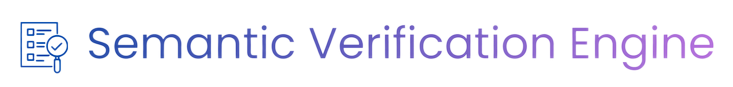

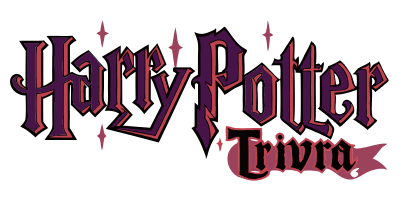

<div style="background-color: #f0e6f7; padding: 10px;">
    <h3 style="text-align:center; color:purple;">Phase 2 Tracer Build: Legacy Data Processing & Sampling </h3>
</div>

## Update Legacy (Baseline v.0.1) dataset to meet Gold Schema 
### (Sprint 2.1)

**Goal**:
 Transform legacy Baseline v.0.1 parquet data into the validated Pydantic *Content Core* required for Phase 2.

**Architectural Decision Records (ADRs) Applied**: Refer to the [design doc](../../docs/00_DESIGN_DOC_AND_ARCHITECTURE.md) for details.
- *ADR-P2-012 (Workflow)*: Implements the *Bootstrap and Scrap* pattern. This notebook serves as a one-time migration lab for the legacy dataset from phase 1. It starts with logic for creating a representative Tracer dataset sample. The notebook will then be upgraded to handle the full legacy dataset. Then the finalized logic specific to the legacy will be scrapped while other methods will modularized into src/ script for Gold Feature Enrichment as required. 
- *ADR-P2-019 (Data Scope)*: Explicit removal of all "Yes/No" (YN) questions. Strategy shifts focus to complex semantic verification (FR, EX, MCQ).

**Strategy (strip & reclothe)**: Removing descriptive features (question_length, answer_type etc) to ensure the Context Refinery generates unified features for both legacy and synthetic sets.

**Manual handoff for tracer build**: Outputting to `data/08-bronze` for manual inspection prior to passing through `qa_validation` pipeline script.

**Workflow**: 
1. Preprocessing:
    - Shed columns that are not in BaseQuestion schema
    - Remove `YN` questions
    - Add `question_source` column filled as enum `QuestionSource.LEGACY`
    - For MCQ: Seperate `question` text into `question` (with question text only str) & `mcq_options` (List[str] = distractors + correct answer ); `answer`
2. LLM enrichment: Loop through questions and fill in missing Schema columns will LLM.
3. Create Phase 2 Tracer dataset
4. Define Legacy schema for Bronze lake entry

---

## Setup and Imports


In [1]:
#  STANDARD NOTEBOOK SETUP
%load_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path
import yaml

sys.path.append('..')
# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
from typing import List, Tuple
from sentence_transformers import util, SentenceTransformer

# --- Project-Specific Imports ---
import ds_utils.notebook_config as nb_cfg
from ds_utils import eda_scripts as eda
from ds_utils.ds_constants import QuestionType, QuestionSource
import ds_utils.tracer_utils as tu
# --- Common Settings ---
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 20)

✅ Notebook config loaded.


---

# 1: Legacy dataset preprocessing

## 1.1 Schema management

In [2]:
# import dataset (output of notebook 2: Baseline Dataset v0.1)
file_path = nb_cfg.INTERMEDIATE_DATA_DIR/ "dataframe_nb4_legacy_cleaned_v0.parquet"
df_loaded_from_checkpoint = pd.read_parquet(file_path)
# set 'original_question' as index
# df_loaded_from_checkpoint = df_loaded_from_checkpoint.set_index(df_loaded_from_checkpoint.columns[0])
df_loaded_from_checkpoint.head()

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword,question_length,answer_length,question_type,answer_type
0,0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang.","[what, be, three, european, wizarding, school,...","[hogwarts, beauxbatons, durmstrang]","[what, be, three, european, wizarding, school,...","[what, be]",what,13,4,FR,text
1,1,When was Hogwarts founded?,10th century,"[when, be, hogwarts, found]","[10th, century]","[when, be, hogwarts, found, 10th, century]","[when, be]",when,4,2,FR,year
2,2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, be, wronski, feint]","[pretend, dive, snitch]","[what, be, wronski, feint, pretend, dive, snitch]","[what, be]",what,5,6,FR,text
3,3,You wouldn't know anything about this. Name a ...,Using polish,"[know, anything, name, method, make, broom, go...","[use, polish]","[know, anything, name, method, make, broom, go...",[name],name,16,2,FR,text
4,4,Harry first took the Knight Bus in The Prisone...,14 sickles.,"[harry, first, take, knight, bus, prisoner, az...","[14, sickle]","[harry, first, take, knight, bus, prisoner, az...","[how, do]",how,22,2,FR,text


In [3]:
df_loaded_from_checkpoint.info()

<class 'pandas.core.frame.DataFrame'>
Index: 895 entries, 0 to 901
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   original_question_id    895 non-null    int64   
 1   question                895 non-null    object  
 2   answer                  895 non-null    object  
 3   question tokens         895 non-null    object  
 4   answer tokens           895 non-null    object  
 5   combined_unique_tokens  895 non-null    object  
 6   interrogative_keywords  895 non-null    object  
 7   main_keyword            895 non-null    object  
 8   question_length         895 non-null    int64   
 9   answer_length           895 non-null    int64   
 10  question_type           895 non-null    category
 11  answer_type             895 non-null    category
dtypes: category(2), int64(3), object(7)
memory usage: 79.1+ KB


In [4]:
## 1. Remove columns not in BaseQuestion schema
columns_to_keep = ['original_question_id','question_type','question','answer']

df_analysis = df_loaded_from_checkpoint[columns_to_keep].copy()
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 895 entries, 0 to 901
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   original_question_id  895 non-null    int64   
 1   question_type         895 non-null    category
 2   question              895 non-null    object  
 3   answer                895 non-null    object  
dtypes: category(1), int64(1), object(2)
memory usage: 29.0+ KB


In [5]:
## 2. Filter out Yes/No questions
print(f"Number of YN questions to remove: {df_analysis[df_analysis['question_type']=='YN'].shape[0]}")
df_analysis = df_analysis[df_analysis['question_type'] != 'YN'].copy()
print(df_analysis['question_type'].value_counts())

# sanity check
print(f"Number of questions remaining after removal: {df_analysis.shape[0]}")

Number of YN questions to remove: 6
question_type
FR     699
EX     102
MCQ     88
YN       0
Name: count, dtype: int64
Number of questions remaining after removal: 889


In [6]:
## 3. Add `question_source` column with default value 'legacy'
df_analysis['question_source'] = QuestionSource.LEGACY.value
df_analysis['question_source'] = df_analysis['question_source'].astype("category")

#sanity check
df_analysis['question_source'].value_counts()

question_source
legacy    889
Name: count, dtype: int64

In [7]:
df_analysis.loc[df_analysis['question_type']=='MCQ','question'].sample(10)

599    Which of these is needed for successful broom ...
618    Which of the following books was NOT written b...
572    Which statement is true about conjured objects...
201    In the Quidditch World Cup, Ireland's team had...
438    Who is NOT in Gryffindor: Harry Potter, Ron We...
597    Which of these plants bloom instantly: Mandrak...
565    In Harry Potter and the Half-Blood Prince, whi...
607    Which of the following is NOT a type of Dark M...
682    Who among the following served as a Hufflepuff...
643    Albus Dumbledore is famous for discovering how...
Name: question, dtype: object

In [8]:
## 4. Extract options from MC questions and create new column 'options'

# helper method to clean individual option strings (remove leading conjunctions, trailing punctuation)
def clean_option(opt: str) -> str:
    opt = opt.strip()
    # Remove leading conjunctions
    opt = re.sub(r"^(or|and)\s+", "", opt, flags=re.IGNORECASE)
    # Remove trailing punctuation / quotes
    opt = re.sub(r'[?."]\s*$', "", opt)
    return opt

# create method to extract options from MCQ question string
def split_mcq_question(question: str) -> Tuple[str, List[str]]:
    """
    MCQ structure: "<question_stem>[.?:] <option A>, <option B>, <option C>, <option D>[.?]"
    Steps:
    1. Split once after the first . ? :
    2. Extract `question stem with punctuation` and `options` strings separately 
    3. Strip trailing punctuation
    4. Split by commas
    5. Clean → List[str]
    """
    # step 1: split once after first . ? :
    parts = re.split(r"([?:])", question, maxsplit=1)
    # parts = [stem, delimiter, remainder]
    assert len(parts) == 3, f"Malformed MCQ: {question}"
    # step 2: get question stem and options strings separately and remove leading/trailing whitespace
    stem = (parts[0] + parts[1]).strip()  # question stem with punctuation
    options_str = parts[2].strip()        
    # step 3: Remove trailing punctuation (., ?) from options string
    options_str = re.sub(r"[?.]\s*$", "", options_str)
    # step 4, 5: Split by commas and create clean list
    options = [
        clean_option(opt)
        for opt in options_str.split(",")
        if opt.strip()
    ]
    return stem, options

MANUAL_CORRECTIONS = {
    1138: {"options": ["A long flowing cloak", "Flying in heavy rain", "Long hair", "An untrimmed broom tail"]},
    1125: {"question": "Which of these is needed for successful broom casting?",
           "options": ["Speed", "Balance", "Courage", "Strength"]},
    1361: {'answer': "as children in a park near their homes before they attended hogwarts",
           "options": ['on the hogwarts express during their first journey to school', 
                       'as children in a park near their homes before they attended hogwarts', 
                       'during the sorting ceremony of their first year', 'in their first potions class', 
                       'taught by professor slughorn']},
    1158: { "question": "which of these plants has healing properties?",
            "options": ['dittany', 'mandrake', "devil's snare", 'wolfsbane']},
    1155: { "options":  ["concentration", "wand power", "hue of the object", "weight of the object"],}
}

# manual corrections for known issues in specific questions
def apply_manual_corrections(
    question_id: int,
    question: str,
    answer: str,
    options: list[str],
) -> tuple[str, str, list[str]]:
    fix = MANUAL_CORRECTIONS.get(question_id)
    if not fix:
        return question, answer, options
    if "question" in fix:
        question = fix["question"]
    if "answer" in fix:
        answer = fix["answer"]
    if "options" in fix:
        options = fix["options"]

    return question, answer, options


# strip whitespace, lowercase, remove trailing punctuation
def standardize_text(text: str) -> str:
    """The 'Universal Grounder' for your text data."""
    if not isinstance(text, str):
        return ""
    # Lowercase, strip whitespace, and remove trailing punctuation
    text = text.lower().strip()
    text = re.sub(r'[?."]\s*$', "", text)
    return text

# apply mcq helpers to each row
def process_mcq_row(row):

    # 1. Split question into stem and options
    stem, raw_options = split_mcq_question(row["question"])

    # 2. Apply manual corrections 
    stem, answer, corrected_options = apply_manual_corrections(
        row["original_question_id"],
        stem,
        row["answer"],
        raw_options
    )

    # 3. Standardize corrections
    options = [standardize_text(opt) for opt in corrected_options]
    answer = standardize_text(answer)
    
    assert isinstance(options, list) and len(options) >= 2
    # assert answer in options, f"Answer not in options for {row['original_question_id']}"

    return pd.Series({
        "question": stem,
        "answer": answer,
        "mcq_options": options
    })


In [9]:
## update dataframe using helper methods
df_mcq = df_analysis[df_analysis['question_type']=='MCQ'].copy()
df_mcq.head()

,original_question_id,question_type,question,answer,question_source
201,341,MCQ,"In the Quidditch World Cup, Ireland's team had...",Troy,legacy
421,749,MCQ,"Who is NOT in Slytherin: Lavender Brown, Pansy...",Lavender Brown,legacy
438,795,MCQ,"Who is NOT in Gryffindor: Harry Potter, Ron We...",Draco Malfoy,legacy
559,1085,MCQ,Which of the following is NOT a form of Transf...,Enchantment,legacy
561,1087,MCQ,Which of the following plants is known for its...,Bouncing Bulbs,legacy


In [10]:
df_mcq[["question", "answer", "mcq_options"]]= (df_mcq.apply(process_mcq_row, axis=1))
# sanity check
df_mcq[['question','mcq_options']].sample(5)

,question,mcq_options
613,Which of these spells can summon an object:,"[accio, alohomora, engorgio, mobilicorpus]"
645,How many O.W.L. (Ordinary Wizarding Level) exa...,"[5, 7, 9, 10]"
569,Which of the following spells is not used in T...,"[vera verto, evanesco, confundo, avis]"
602,Which of the following is another dive commonl...,"[porskoff ploy, bludger backbeat, spiral dive,..."
572,Which statement is true about conjured objects:,[they are permanent if the caster is powerful ...


In [11]:
df_mcq[df_mcq['original_question_id']==1138][['question','mcq_options']]

,question,mcq_options
612,"According to Madam Hooch, which of the followi...","[a long flowing cloak, flying in heavy rain, l..."


In [12]:
df_mcq[df_mcq['original_question_id']==1361]

,original_question_id,question_type,question,answer,question_source,mcq_options
835,1361,MCQ,When did Lily Evans first meet Severus Snape:,as children in a park near their homes before ...,legacy,[on the hogwarts express during their first jo...


In [13]:
# remove old mcq questions from df_analysis and append correct ones from df_mcq

# 1. create a `mcq_options` column in df_analysis with empty lists for non-MCQ questions
if "mcq_options" not in df_analysis.columns:
    df_analysis["mcq_options"] = pd.NA

# 2. remove old MCQ questions from df_analysis
df_analysis_no_mcq = df_analysis[df_analysis['question_type'] != 'MCQ'].copy()

# 3. align columns (concat safety)
df_mcq = df_mcq[df_analysis_no_mcq.columns]

# 4. append updated MCQ questions to df_analysis_no_mcq
df_analysis = pd.concat([df_analysis_no_mcq, df_mcq],ignore_index=True)

# 5. View results
display(df_analysis.info())
display(df_analysis['question_type'].value_counts())
display(df_analysis.sample(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   original_question_id  889 non-null    int64   
 1   question_type         889 non-null    category
 2   question              889 non-null    object  
 3   answer                889 non-null    object  
 4   question_source       889 non-null    category
 5   mcq_options           88 non-null     object  
dtypes: category(2), int64(1), object(3)
memory usage: 30.0+ KB


None

question_type
FR     699
EX     102
MCQ     88
YN       0
Name: count, dtype: int64

,original_question_id,question_type,question,answer,question_source,mcq_options
454,841,FR,Who founded St Mungo's Hospital?,Mungo Bonham,legacy,NaN
525,1028,FR,What trait did Godric Gryffindor value most in...,Courage,legacy,NaN
313,540,FR,What was the name of the company Vernon Dursle...,Grunnings,legacy,NaN
181,304,FR,Which of Voldemort’s Horcruxes do Harry and Du...,Slytherin’s locket,legacy,NaN
87,128,FR,"In Book 2, who is the first victim to be petri...","Filch's cat, Mrs. Norris.",legacy,NaN
646,1266,FR,Which rarely offered elective at Hogwarts is r...,Alchemy,legacy,NaN
322,562,FR,What is the name of the magical object that al...,The Cloak of Invisibility,legacy,NaN
327,569,FR,What item in the Headmaster's Office allows yo...,The Pensieve,legacy,NaN
86,127,FR,What is the opposite of conjuration?,Vanishment,legacy,NaN
743,1370,FR,When did Dumbledore become the master of the E...,"In 1945, after defeating Gellert Grindelwald i...",legacy,NaN


In [14]:
## dataframe mcq_options sanity check

# 1. make sure all other question types of mcq_options as NaN
assert df_analysis.loc[
    df_analysis["question_type"] != "MCQ",
    "mcq_options"
].isna().all(), "Non-MCQ rows should not have mcq_options"
# 2. make sure all MCQ questions have non-empty mcq_options
assert df_analysis.loc[
    df_analysis["question_type"] == "MCQ",
    "mcq_options"
].apply(lambda x: isinstance(x, list) and len(x) > 0).all(), "MCQ rows should have non-empty mcq_options"

In [15]:
# Logical reordering of columns
desired_column_order =["original_question_id", "question_source", "question_type", "question", "mcq_options", "answer"]
df_analysis = df_analysis[desired_column_order]
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   original_question_id  889 non-null    int64   
 1   question_source       889 non-null    category
 2   question_type         889 non-null    category
 3   question              889 non-null    object  
 4   mcq_options           88 non-null     object  
 5   answer                889 non-null    object  
dtypes: category(2), int64(1), object(3)
memory usage: 30.0+ KB


The legacy dataset is now ready for LLM processing.

---


## 1.2: Prompt iteration
Columns that need to be filled:
- `answer_variations` for FR & EX as a `List[str]`,
- `hint 1`, `hint 2`, `hint 3`, `explanation` for all question types 
- `explanation` as str

#### Initial Prompt

<details>
<summary><strong>Full Prompt – Initial Legacy Baseline Enrichment</strong></summary>
<blockquote>
You are generating learning scaffolding for these Harry Potter trivia questions.

{Question_dict}

Return a JSON object with:
- hint_1: very subtle nudge
- hint_2: medium hint
- hint_3: strong hint (points clearly toward the answer WITHOUT naming it). Hint 3 may describe context, but must not uniquely identify the answer on its own.
- explanation: short, clear explanation (2–4 sentences)
- answer_variations: a list of 4 valid alternative phrasings of the answer

Rules:
- Do not invent facts
- Keep language age-appropriate
- Hints must NOT include the answer text, proper names, or titles verbatim
- Hint 3 may describe defining attributes or context, but must not explicitly name the answer
- Variations must be semantically equivalent to the answer
- For numeric answers, answer variations should focus on the numeric value itself (e.g., digits or number words). Do not include explanatory phrasing.
- For numeric answers, generate 2–3 variations if no additional valid surface forms exist. Do not invent formatting variants to meet a quota
- The explanation MAY name the answer explicitly
- Return ONLY valid JSON
</blockquote>
</details>

#### Findings from Prompt Iterations

The prompt was iterated through Google AI Studio (using Google Gemini 3 Flash) to improve output quality prior to API usage. Key issues identified and addressed:

|**Issue**|**Findings**|**Action**|
|-|-|-|
|`hint_3` answer leakage|Early iterations allowed hint_3 to reveal the answer directly or via near-verbatim contextual phrasing|Prompt tightened to ensure `hint_3` remains strongly suggestive but doesn't disclose the answer.|
|`answer_variation` drift into explanations| Variations frequently expanded into explanations or justifications rather than representing the answer itself. This diluted the semantic core of the correct answer, especially for FR questions.|Explicit guidance added to keep variations concise and answer-focused.|
|Numeric answer drift| Produced verbose  explanatory variants (e.g. “5 exceptions”, “exactly five”). This weakened numeric (core ans) anchoring for downstream semantic matching|Added explicit rules constraining numeric variations to digits or number-word forms only|
|Quota pressure for `answer_variations`| Requiring a fixed number of answer variations caused the model to invent low-quality padding (e.g. generic entities, weak MCQ shortcuts)| Added guidelines for various `answer_type`. Prompt continues to request up to 4 variations for generation flexibility; post-processing validation in `qa_validation` will trim redundancy and enforces tighter variation ranges by question type.|
|MCQ specificity sensitivity|MCQs require higher semantic precision than FR/EX questions. Over-generating variations led to ambiguity or incorrect generalization (e.g. correct answer: Whomping Willow → variation: Willow tree). While this may resolve correctly in a closed MCQ option set, it would be incorrect in an FR context.| Handle with post-processing: limit accepted MCQ variations, enforce uniqueness against distractors, and require clear semantic score separation between correct option and all distractors|
|Missing contextual (semantic) variations| `answer_variations` capture lexical / surface-level variations but miss contextual and HP specific terms (e.g. harry potter vs. the-boy-who-lived). These are required for SBERT fine-tuning and for robust contextual answer checking.|Introduce a second offline LLM batch to generate semantic_variations per unique canonical answer, decoupled from question phrasing.. Answer checking logic for current phase: *Exact match → Fuzzy match → sbert (answer text vs. lexical varations) → sbert (semantic variations)|
| Batch size viability| The prompt successfully handled ~15 questions per batch in Google AI Studio without noticeable degradation in instruction adherence, schema consistency, or cross-question contamination| Adopt ~10–15 questions per batch as the default unit for tracer runs and offline enrichment to balance quality, debuggability, and throughput|
|Cost & configuration signal| Initial cost estimates using **Gemini 3** (default temperature, medium intelligence) showed that enriching ~15 questions per batch is cost-efficient, projecting a low single-digit dollar cost for full-dataset enrichment (~ tracer (20~50 questions) <$1 and full legacy update (~920 questions) is ~$3). The more extensive runs are with synthetic generation though. These estimates informed tracer sizing only; full synthetic generation cost modeling is handled separately.| Proceed with tracer and early enrichment using this configuration; defer optimization (temperature tuning, model tier changes) until after tracer validation confirms pipeline behavior|
|Change in generation models over time (e.g. Gemini 2.5 pro no longer available in free-tier) |Confirmation that the single SBERT model invariant is effective. The LLM used for generation may evolve, be swapped, or used in a hybrid approach, but all semantic comparison, validation thresholds, and training assumptions are anchored to a single, stable embedding space (SBERT).|If that embedding model changes, all Gold embeddings must be regenerated|


#### Final Prompt (Tracer Baseline)

The prompt below is a snapshot of the prompt used for this experiment run. It takes a batch of ~15 questions in a dict to batch process together.

**Source of truth:** [`scripts/research/question_generation/iterations/legacy_enrichment_v0.txt`](scripts/research/question_generation/iterations/legacy_enrichment_v0.txt) → If discrepancies exist, the file version takes precedence.

<details>
<summary><strong>Full Prompt – Final Legacy Baseline Enrichment for Phase 2 Tracer (v0)</strong></summary>

<blockquote>
You are generating learning scaffolding for a Harry Potter trivia ---QUESTIONS DICTIONARY--- provided.
You must follow the instructions and format precisely. Use the ---EXAMPLES--- provided to understand the desired quality and structure.

You are given:
- question_id: dictionary key that identifies each question
- question_type: one of {FR, EX, MCQ}
- question: the trivia question
- answer: the canonical correct answer (string)
- (for MCQ only) mcq_options: list of answer choices
- answer_form: one of {entity, numeric, action, explanatory, date}
- (optional, for date answers) date_precision_required: one of {year, month, day}

Your task is to return a JSON object with:
- question_id: the exact question id for the question
- question_type: the exact question type for the given question
- question: exact question text provided.
- answer: exact answer text provided.
- hint_1: a very subtle nudge
- hint_2: a medium-strength hint
- hint_3: a strong hint (nearly gives it away, but does NOT state the answer verbatim)
- explanation: a short, clear explanation (2–4 sentences)
- answer_variations: a list of valid alternative phrasings of the answer

### General rules (apply to all question types)

- Do NOT invent facts.
- Keep language age-appropriate.
- Hints must not reveal the answer verbatim. 
- Hints must not include any word, phrase, or identifier that would be accepted as a correct answer if typed by the learner. This includes canonical answers, aliases, titles, identities, exact terms, or uniquely identifying phrases.
- Hint 3 may describe attributes, roles, effects, or context, but must avoid uniquely identifying the answer on its own.
- The explanation must justify why the answer is correct. 
- Answer variations must be semantically equivalent to the canonical answer.
- Answer variations should represent the answer itself, not its justification.

### Question-type–specific guidance

#### FR (Free Response)
- Answer variations should capture reasonable ways a learner might express the correct answer.
- Answer variations should represent the full answer as it would be stated in isolation. Partial names or fragments that rely on external context should be avoided.
- Avoid drifting into full explanations or new facts.

#### EX (Explanatory)
- Answer variations may paraphrase the explanation briefly.
- Preserve the same core meaning without adding new information.
- Hint 3 should surface the conceptual lens (theme, motive, character insight) without stating the resolved conclusion or outcome.

#### MCQ (Multiple Choice)
- Generate hints and explanation as if the learner does NOT see the correct option highlighted.
- Hint 1 should activate relevant recall or reasoning (rules, context, constraints), not restate the question setup.
- Hints should guide reasoning toward the correct option, not eliminate options mechanically.
- Answer variations may include:
  - key terms
  - short phrases
  - partial answer keywords
  that a learner might reasonably type instead of the full option text.
- Variations must still uniquely identify the correct option among the given choices.
- Do NOT include distractor options or ambiguous fragments.
- The explanation must not reference option labels, ordering, or eliminate options explicitly.

### Answer-variation guidelines by answer_form

1. entity
   - Variations may include name ordering, aliases, or commonly accepted equivalents.
   - Do NOT introduce titles, roles, or honorifics unless they are part of the canonical answer
     or required by the question.

2. numeric
   - Variations should focus on the numeric value itself (digits or number words).
   - Do NOT invent formatting variants (e.g., leading zeros).
   - Generate fewer variations if no additional valid surface forms exist.

3. action
   - Variations may describe the same action or use-case concisely.
   - Avoid full cause–effect explanations.

4. explanatory
   - Variations may paraphrase the explanation briefly.
   - Avoid expanding scope or introducing additional facts.

5. date
   - Variations should represent the same date at the allowed precision.
   - Prefer standard, commonly used date formats.
   - Do NOT include unrelated temporal context.


### Output rules
- Return ONLY a single valid JSON object keyed by question_id, where each value is the generated scaffold.
- Do NOT include commentary, markdown, or extra text.

---EXAMPLES---

[   
  {{
        "question_id": 801,<br>
        "question_type": "FR",<br>
        "question": "Who is the 'Half-Blood Prince' mentioned in the title of the sixth book?",<br>
        "answer": "Severus Snape",<br>
        "hint_1": "The title refers to a nickname written inside an old Potions textbook.",<br>
        "hint_2": "The person behind this name eventually becomes the Headmaster of Hogwarts.",<br>
        "hint_3": "This individual was a master of the Dark Arts and the long-time rival of James Potter during their school years.",<br>
        "explanation": "Severus Snape gave himself the title 'Half-Blood Prince' to honor his mother, Eileen Prince, and to acknowledge his status as the son of a Muggle father. Harry unknowingly follows the Prince's expert notes in his Advanced Potion-Making class.",<br>
        "answer_variations": [
        "Severus Snape",
        "Snape",
        "Professor Snape",
        "Professor Severus Snape"
    ]<br>
  }},
  {{
    "question_id": 802,<br>
    "question_type": "MCQ",<br>
    "question": "Which of these magical creatures can only be seen by individuals who have witnessed death?",<br>
    "answer": "Thestral",<br>
    "mcq_options": ["Hippogriff", "Phoenix", "Thestral", "Basilisk"],<br>
    "hint_1": "Recall the unseen force that pulls the carriages into the school gates.",<br>
    "hint_2": "Most students think the carriages move by themselves, but Harry sees them as skeletal, winged horses.",<br>
    "hint_3": "These beings only become visible once a person has emotionally processed the loss of a life.",<br>
    "explanation": "Visible only to those who have seen death, these creatures are often misunderstood. Harry begins seeing them in his fifth year after witnessing Cedric's death.",<br>
    "answer_variations": ["Thestrals"]<br>
  }},
  {{
    "question_id": 803,<br>
    "question_type": "EX",<br>
    "question": "Why did Harry survive the Killing Curse in the Forbidden Forest?",<br>
    "answer": "Voldemort used Harry's blood to regenerate his body, unknowingly anchoring Lily's protection to himself.",<br>
    "hint_1": "The reason lies in the dark ritual performed in the graveyard three years prior.",<br>
    "hint_2": "Think about the shared connection between the hero and his nemesis that goes beyond a scar.",<br>
    "hint_3": "Consider the irony: in his quest for invincibility, the villain accidentally turned himself into a living safeguard for the hero's life.",    "explanation": "By taking Harry's blood, the Dark Lord unwittingly preserved the protection of Lily's sacrifice within his own body, acting as a tether for Harry's life.",<br>
    "answer_variations": [
      "Lily's protection was kept alive in Voldemort's body",
      "Voldemort's use of Harry's blood created a life-tether",
      "The sacrifice lived on in the villain because of the shared blood",
      "Voldemort unknowingly acted as a Horcrux-like anchor for Harry"
    ]<br>
  }}
]
---END EXAMPLES---

---QUESTIONS DICTIONARY---

{question_dict}

---END QUESTIONS DICTIONARY---
</blockquote>

</details>

**Next steps:**
1. confirm that `Gemini 2.5 Flash` is suitable for enriching the legacy baseline dataset update.
2. add a semantic / contextual anchor for each answer to the legacy dataset tocapture semantic / in-universe paraphrases of answers.
This serves as an interim semantic anchor for tracer validation and answer checking, and will later inform SBERT fine-tuning.
3. create a selective, representative sample of the legacy dataset for the phase 2 tracer run (~50 to ~60 questions) 

### Results with Gemini 2.5 Flash API calls
- Full outputs are available [here](../../scripts/research/question_generation/llm_outputs/legacy_baseline_enrichment_v.1.2_candidate_1.json)
- The prompt is effective overall. Some residual issues remain, including occasional `hint_3` answer leakage and weak or repetitive answer variations. To address this, prompt instructions were clarified and reinforced using few-shot examples.
- Similar issues were observed when testing with a higher-capability model (Gemini 3 Thinking), indicating these are not model-specific failures but inherent limitations arising from competing generation constraints, e.g.:
    - requiring `hint_3` to be the most helpful while prohibiting the use of any answer-identifying tokens,
    - enforcing a fixed or minimum number of `answer_variations` while also preventing semantic dilution or incorrect generalization,
    - supporting both FR/EX and MCQ behaviors within a single prompt.
- These limitations are expected and are best handled through deterministic post-processing in the qa_validation pipeline, rather than further prompt tightening. Planned validation checks include:
    - detecting answer leakage in hints
    - ensuring MCQ answer variations maintain sufficient semantic separation from distractors
    - enforcing specificity and correctness of answer variations for EX-type questions
- For EX-type questions, Flash produces sufficiently clear hints and explanations for the legacy update. Higher-capability models (e.g. Pro or thinking variants) can improve stylistic and conceptual richness but are not required at this stage.

- **Conclusion**: Gemini 2.5 Flash is sufficient for hint generation, explanations, and answer variations across all question types for the legacy dataset update. Known limitations are predictable and manageable through post-processing validation.

### Add semantic, contextual anchor to answer

The purpose of adding a contextual layer to answers is to enable the SBERT model to better understand the Harry Potter universe within the trivia domain. While some entities and concepts overlap with the real world, others have meanings that are specific / unique to the Harry Potter canon. The contextual answer column provides space for the model to learn which concepts align with its general training and which are universe-specific, allowing semantic comparisons to remain technically correct within the project’s domain.

Initial iterations were working for facts and entities. The prompt had to be clarified on how to handle explanatory questions. The model here was collapsing to providing lexical variations only. in some cases this would be unavoidable but in others it should be clearly anchored in HP lore. Contextual variations represent alternative in-universe references or conceptual handles for the same answer. For abstract or explanatory answers, these may partially overlap with lexical paraphrases since there are fewer distinct semantic representations.

Contextual (semantic) variations are intentionally constrained to canon-anchored lore references. While this helps encode Harry Potter–specific meaning for downstream semantic matching and SBERT fine-tuning, it is inherently limited. LLMs lack a persistent, structured representation of the HP universe’s entities, relationships, and magical rules. As a result, contextual coverage is partial and uneven across question types. This limitation is accepted for Phase-2 and motivates future exploration of explicit knowledge-graph support.

#### Final prompt iteration

The text of the prompt is provided below for reference.
The prompt was tested with the same `question_dict` with 3 different model variations (Gemini 2.5 Flash, 2.5 Pro, 3.0 Flash). For the tracer, the goal was to assess prompt feasibility considering whether:
- the generated contextual variations provide adequate semantic grounding for SBERT-based answer checking and future fine-tuning.
- higher-capability models produce materially better outputs than Gemini 2.5 Flash that would justify shifting generation to a paid tier.

**Conclusion**: Gemini 2.5 Flash is sufficient for generating contextual answer variations. While Gemini 2.5 Pro produces richer and more expressive phrasing, the resulting variations are within the same semantic space and don't meaningfully improve downstream performance.

<details>
<summary><strong>Full Prompt – Legacy Baseline Enrichment - adding contextual variation for answers</strong></summary>

<blockquote>
You are generating in-universe semantic context for Harry Potter trivia answers.

You must follow the instructions and format precisely.
Use the ---EXAMPLES--- provided to understand the desired quality and boundaries.

You are given:
- question_id: dictionary key that identifies each question
- question_type: one of {FR, EX, MCQ}
- question: the trivia question
- answer: the canonical correct answer (string)
- (for MCQ only) mcq_options: list of answer choices

Your task is to return a JSON object with:
- question_id: the exact question id
- contextual_variations: a list of in-universe semantic equivalents of the answer

### Core Intent

Contextual variations are NOT lexical rephrasings.

They are:
- in-universe descriptions
- aliases
- epithets
- narrative roles
- lore-grounded identifiers

that a Harry Potter–knowledgeable learner would reasonably associate
with the same answer.

These variations are intended to support:
- semantic answer checking (SBERT)
- future SBERT fine-tuning
- in-universe contextual understanding

---

### General Rules (Strict)

- Do NOT invent facts.
- Do NOT speculate beyond canon.
- Do NOT introduce new plot information.
- Do NOT include explanations or reasoning chains.
- Do NOT repeat or lightly paraphrase the canonical answer.
- Do NOT include real-world metaphors or non-HP terminology.

Each variation must:
- clearly refer to the same entity / concept
- be grounded in Harry Potter lore
- be understandable without restating the answer verbatim

---

### Question-Type Guidance

#### FR (Free Response)
- Variations may include:
  - aliases
  - familial or social identity
  - narrative descriptors
- Avoid generic or partial references that would be ambiguous out of context.

#### EX (Explanatory)
- Variations should reflect:
  - thematic role
  - narrative function
  - magical or mythological significance
- Avoid restating the explanation itself.

#### MCQ (Multiple Choice)
- Variations must:
  - uniquely identify the correct option
  - NOT overlap semantically with distractors
  - remain valid even if the option list is hidden
- Be more conservative than FR/EX.

---

### What Counts as a GOOD Contextual Variation

✔ Canonical aliases  
✔ Narrative epithets  
✔ Lore-based roles or identifiers  
✔ In-universe descriptions commonly used in the books  

### What Does NOT Count

✘ Surface rewordings  
✘ Partial names only (“Lestrange”, “Willow”)  
✘ Pure explanations  
✘ Meta descriptions (“the correct answer”)  

---

### Output Rules

- Return ONLY valid JSON.
- One object per question_id.
- Do NOT include commentary, markdown, or extra text.

---

---EXAMPLES---

[
  {
    "question_id": 801,
    "contextual_variations": [
      "The Boy Who Lived",
      "The Chosen One",
      "The wizard who survived the Killing Curse"
    ]
  },
  {
    "question_id": 428,
    "contextual_variations": [
      "The fanatical Death Eater cousin of Sirius Black",
      "A member of the Black family who served Voldemort",
      "The witch who struck Sirius during the battle in the Department of Mysteries"
    ]
  },
  {
    "question_id": 633,
    "contextual_variations": [
      "The violent magical tree guarding a hidden passage at Hogwarts",
      "The enchanted tree planted on the Hogwarts grounds that attacks intruders"
    ]
  }
]

---END EXAMPLES---

---QUESTIONS DICTIONARY---
question_dict = {
  ...
}
---END QUESTIONS DICTIONARY---
</blockquote>
</details>

Gemini 2.5 Flash response can be found [here].

# 2:  Phase 2 Tracer Dataset

Create a representative sample of Legacy dataset for Phase 2 Tracer build

temporarily add `answer_type` column back to strategically select questions to best test the qa_validaiton, answer-checking logic and other logic downstream.

In [16]:
# Temporarily add `answer_type` and `main_keyword` for selectively adding questions for tracer sample
df_analysis = pd.merge(df_analysis, df_loaded_from_checkpoint[['original_question_id','answer_type', 'main_keyword']],
                       on='original_question_id', how='left')
# sanity check
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   original_question_id  889 non-null    int64   
 1   question_source       889 non-null    category
 2   question_type         889 non-null    category
 3   question              889 non-null    object  
 4   mcq_options           88 non-null     object  
 5   answer                889 non-null    object  
 6   answer_type           889 non-null    category
 7   main_keyword          889 non-null    object  
dtypes: category(3), int64(1), object(4)
memory usage: 38.0+ KB


In [17]:
# distribution of answer types per question type
df_analysis.groupby(['question_type','answer_type'], observed=False).size()

question_type  answer_type
EX             date             0
               numeric          0
               text           102
               year             0
FR             date             7
               numeric         26
               text           657
               year             9
MCQ            date             0
               numeric          6
               text            82
               year             0
YN             date             0
               numeric          0
               text             0
               year             0
dtype: int64

Since the FR questions with text answers is disproportionetly large. We can take a further granular look in here to make sure sampling here is representative and edge case for logic testing are included for the tracer.

In [18]:
# Filter FR questions with text answers (baseline)
fr_text_questions = df_analysis.loc[(df_analysis['question_type']=='FR')&(df_analysis['answer_type']=='text')]
# Group by the main (interrogative) keyword to ensure diversity in question phrasing for FR / text answers
fr_text_questions.groupby('main_keyword', observed=False).size()

main_keyword
how        8
name      10
what     375
when      17
where     31
which    104
who      112
dtype: int64

In [19]:
# Filter FR questions with text answers (baseline)
fr_text_questions = df_analysis.loc[df_analysis['question_type']!='FR']
# Group by the main (interrogative) keyword to ensure diversity in question phrasing for FR / text answers
fr_text_questions.groupby(['question_type','main_keyword'], observed=True).size()

question_type  main_keyword
EX             how             33
               what            33
               where            2
               which            2
               who              3
               why             29
MCQ            how              6
               what             7
               when             2
               which           67
               who              5
               why              1
dtype: int64

## 2.1: Legacy dataset stratification sampling strategy

Using the breakdown, we can use stratified sampling to create the legacy sample dataset for the phase 2 tracer build. The aim is to check downstream logic of the validation pipeline and the hybrid answer checker. This requires representations of all types of questions so that any failures or weak points can surface and be addressed early on.

| Question type | Sample Count (answer_types) |subcategorization by `main_keyword` | Test for|
|-|-|-|-|
|**Explanatory (EX)**| 30 x text| always include rare occuring keywords: 7 counts of `where`, `who`, `which`. Remaining common keywords `how`, `what`, `why` equally sampled|longest explanations, most semantic variation, highest hint leakage risk, test SBERT semantic anchoring|
|**Factual Recall (FR)**| 25 x text,<br>5 x numeric,<br>5 x year,<br>5 x date | **Within  25 x text answers only**: will be split into:<br> [6x 'what', 5x 'which', 5x 'who', 2x'how', 2x'name', 2x 'when', 3x 'where'] | Text is baseline (most common type). Since the text answers is disproportionately large segment of the dataset, this is further split by main keywords. It tests for the most common (`what`, `which`, `who`) along with other keywords as edge cases. Other answer types test edge behavior for answer checking logic and validation|
|**MCQ**|25 x text,<br> 5 x numeric|No special consideration|semantic distance between correct vs distractors, partial-answer handling, overgeneralization (“Willow” vs “Whomping Willow”). Numeric answers are edge cases for answer checking logic|


### High-level criteria for selecting hard / edge cases 

Furthermore, within each dataset category identified, a *hard* case will be selected to stress test the downstream logic.

Category|Hard case criteria|Explanation|
|-|-|-|
|EX (Text)|multi-step explanation| Questions where the answer has two distinct parts| Tests if SBERT behaviour with ambiguity / threshold logic / handling partial answer logic|
|FR (Text)|*Alias* challenge|Questions where the character has many names (e.g., Tom Riddle / Voldemort / He Who Must Not Be Named)|
|FR (Numeric)|*Unit* ambiguity|Questions where the answer could be "7" or "seven" or "seventh year". Tests answer normalization, parsing, false positives|
|MCQ|Close distractors (high lexical overlap)|Options that are semantically very similar. Tests the limits of the semantic difference threshold between options as well as validation logic for MCQ questions in qa pipeline|
|MCQ|possible partial answer / player shorthand|Tests answer logic if it can distinguish answer from distractors with partial entry or semantic equivalent (e.g. “Willow” instead of “Whomping Willow”, or nickname vs full option text)|


## 2.2: Tracer dataset baseline
**Sampling methodology**
1. A stratified random sample was first generated using a fixed random seed to ensure reproducibility and representative coverage across question types and answer types.
2. The resulting sample was then manually reviewed to confirm inclusion of at least one hard / edge case per category (as defined in the criteria above).
3. In cases where a suitable hard case was not present in the random sample, a minimal number of questions were manually added to ensure downstream validation logic (qa_validation and hybrid answer checking) is exercised under known stress conditions. This manual augmentation is intentional and scoped, and does not replace the underlying random sampling strategy.

In [20]:
RANDOM_SEED = 26

## Requirements for each question type
# multiple choice questions (MCQ)
num_total_mcq = 30
num_mcq_text=25
# Explanatory (EX)
num_ex_total = 30
rare_ex_keywords = ['where', 'who', 'which']
# Factual Recall (FR)
num_fr_total = 40
num_fr_text = 25
num_other = 5
fr_other_ans_types = ['numeric', 'year', 'date']

## A. Multiple choice questions (MCQ) -> 25 text answers, 5 numeric answers
mcq_text = df_analysis.loc[(df_analysis['question_type']=='MCQ')&(df_analysis['answer_type']=='text')]
mcq_numeric = df_analysis.loc[(df_analysis['question_type']=='MCQ')&(df_analysis['answer_type']=='numeric')]

mcq_sample = pd.concat([
    mcq_text.sample(n=num_mcq_text, random_state=RANDOM_SEED),
    mcq_numeric.sample(n=(num_total_mcq-num_mcq_text), random_state=RANDOM_SEED)])

# sanity check
actual_mcq = mcq_sample['answer_type'].value_counts()
assert actual_mcq.get('text') == 25, f"Expected 25 text, got {actual_mcq.get('text')}"
assert actual_mcq.get('numeric') == 5, f"Expected 5 numeric, got {actual_mcq.get('numeric')}"

## B. Explanatory questions (EX) -> Total all rare main_keywords, sampled other main_keywords
filter_ex_rare = (df_analysis['question_type']=='EX') & (df_analysis['main_keyword'].isin(rare_ex_keywords))
ex_required = df_analysis[filter_ex_rare]
num_ex_other = num_ex_total - ex_required.shape[0]  # 23
ex_other_filter = (df_analysis['question_type'] == 'EX') & (~df_analysis['main_keyword'].isin(rare_ex_keywords))
ex_other = df_analysis.loc[ex_other_filter].sample(n=num_ex_other, random_state=RANDOM_SEED)

ex_sample = pd.concat([ex_required, ex_other])

# sanity check
assert ex_sample.shape[0] == num_ex_total, "EX sample size mismatch"
assert set(rare_ex_keywords).issubset(set(ex_sample['main_keyword'].unique())), "EX rare keywords missing"

## C. Factual Recall questions (FR) -> 25 x text, 5 x numeric,5 x year, 5 x date
# 1. Sample FR questions that do not have text answers
list_of_fr_samples= []
total_num_sampled = 0
# get samples for each of the other answer types
for ans_type in fr_other_ans_types:
    subset = df_analysis.loc[(df_analysis['question_type']=='FR') & (df_analysis['answer_type']==ans_type)]
    n_sample = min(num_other, len(subset))
    fr_other = subset.sample(n=n_sample, random_state=RANDOM_SEED)
    list_of_fr_samples.append(fr_other)
    total_num_sampled += n_sample
# concatenate other answer type samples together
other_fr_answers_df = pd.concat(list_of_fr_samples)
# sanity checks
assert other_fr_answers_df.shape[0] == total_num_sampled, "FR other answer types sample size mismatch"
assert total_num_sampled == 15, "FR other answer types total sample size mismatch"
actual_counts = other_fr_answers_df['answer_type'].value_counts()
actual_counts = actual_counts[actual_counts > 0].to_dict()  # drop categories e.g. YN that are 0
expected_counts = {'numeric': 5, 'year': 5, 'date': 5}
assert actual_counts == expected_counts  
assert all(actual_counts.get(k) == v for k, v in expected_counts.items())

# 2. Sample FR questions with text answers
fr_text_filter = (df_analysis['question_type']=='FR') & (df_analysis['answer_type']=='text')
required_keyword_sampling = {'what':6, 'which':5,'who':5,
                             'how':2,'name':2,'when':2,'where':3}

list_of_fr_text_samples = []
for keyword, n_samples in required_keyword_sampling.items():
    subset = df_analysis.loc[fr_text_filter & (df_analysis['main_keyword']==keyword)]
    n_sample = min(n_samples, len(subset))
    fr_text_sampled = subset.sample(n=n_sample, random_state=RANDOM_SEED)
    list_of_fr_text_samples.append(fr_text_sampled)
fr_text_answers_df = pd.concat(list_of_fr_text_samples)

# sanity checks
assert fr_text_answers_df.shape[0] == num_fr_text, "FR with text answer count does not match required"
actual_fr_counts = fr_text_answers_df['main_keyword'].value_counts().to_dict()
expected_fr_counts = {'what': 6, 'which': 5, 'who': 5, 'how': 2, 'name': 2, 'when': 2, 'where': 3}
assert actual_fr_counts == expected_fr_counts, "FR counts by main keyword do not match"

# concatenate all FR samples together
fr_sample = pd.concat([other_fr_answers_df, fr_text_answers_df])

# sanity checks
assert fr_sample.shape[0] == num_fr_total, "FR sample size mismatch"
actual_fr_sample_counts = fr_sample['answer_type'].value_counts().to_dict()
expected_fr_sample_counts = {'text':25, 'numeric':5, 'year':5, 'date':5}
assert actual_fr_sample_counts == expected_fr_sample_counts, "FR counts by answer do not match"

## D. Create Tracer Dataset
tracer_df = pd.concat([mcq_sample, ex_sample, fr_sample], ignore_index=True)

In [21]:
## Create report for visual checks of the Tracer dataset

print("### Tracer Dataset Audit Report ###\n")
# 1. Schema & Integrity
print("1. Structure & Null Check:\n")
tracer_df.info()

# 2. Lore/Context Check
print("\n2. Representative Samples:")
# Highlight specific columns to avoid horizontal scrolling
cols_to_show = ['question_type', 'question', 'answer', 'answer_type', 'main_keyword']
display(tracer_df[cols_to_show].sample(5, random_state=RANDOM_SEED))

# 3. Stratification Verification
print("\n3. High-level stratification (question type x answer Type):")
summary_1 = (
    tracer_df.groupby(['question_type', 'answer_type'], observed=True)
    .size()
    .reset_index(name='sample_count')
    .sort_values(by=['question_type', 'sample_count'], ascending=[True, False])
)
display(summary_1)

# 4. Keyword Distribution (The "Keyword Balance" Report)
print("\n4. Main keyword distribution (text-only EX and FR):")
tracer_text = tracer_df.loc[(tracer_df['question_type'].isin(['EX', 'FR'])) & (tracer_df['answer_type']=='text')]
summary_2 = (
    tracer_text.groupby(['question_type', 'main_keyword'], observed=True)
    .size()
    .unstack(fill_value=0)
).T
display(summary_2)


### Tracer Dataset Audit Report ###

1. Structure & Null Check:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   original_question_id  100 non-null    int64   
 1   question_source       100 non-null    category
 2   question_type         100 non-null    category
 3   question              100 non-null    object  
 4   mcq_options           30 non-null     object  
 5   answer                100 non-null    object  
 6   answer_type           100 non-null    category
 7   main_keyword          100 non-null    object  
dtypes: category(3), int64(1), object(4)
memory usage: 4.8+ KB

2. Representative Samples:


,question_type,question,answer,answer_type,main_keyword
8,MCQ,which of these plants has healing properties?,dittany,text,which
69,FR,When did the wildcat gargoyle strike the place?,1911,year,when
84,FR,Which potion might a studious witch like Hermi...,Wideye Potion (also known as the Awakening Pot...,text,which
41,EX,How did Fred and George get the money to open ...,Harry gave Fred and George his triwizard tourn...,text,how
25,MCQ,What was the number of the high-security Gring...,713,numeric,what



3. High-level stratification (question type x answer Type):


,question_type,answer_type,sample_count
0,EX,text,30
3,FR,text,25
1,FR,date,5
2,FR,numeric,5
4,FR,year,5
6,MCQ,text,25
5,MCQ,numeric,5



4. Main keyword distribution (text-only EX and FR):


question_type,EX,FR
main_keyword,,
how,9,2
name,0,2
what,8,6
when,0,2
where,2,3
which,2,5
who,3,5
why,6,0


## 2.3: Add *hard* edge cases

### 2.3.1. Explanatory (text) answers

In [22]:
audit_df = tracer_df.copy()

## 1. EX: multistep explanation
# filter the top 5 longest answers and assess -> uses word count helper from src/ds_utils/eda_script
complex_ex = (
    audit_df[audit_df['question_type'] == 'EX']
    .assign(word_count=eda.get_clean_word_counts(audit_df, 'answer'))
    .sort_values('word_count', ascending=False)
)
display(complex_ex[['original_question_id', 'question', 'answer', 'word_count']].head(5))

,original_question_id,question,answer,word_count
46,1369,Why did Voldemort seek out the imprisoned Gell...,Voldemort wanted to force Grindelwald to revea...,40
50,1401,"In Chamber of Secrets, what secret did Harry d...",He was falsely accused by Tom Riddle (Lord Vol...,29
56,1345,What was the second true prophecy made by Prof...,"That the Dark Lord would rise again, and his s...",25
34,1357,"Who had Severus Snape’s true allegiance, and why?",Albus Dumbledore: Snape's allegiance was to hi...,23
53,1358,Why was Sirius Black sent to Azkaban?,He was wrongly accused of betraying the Potter...,22


In [23]:
complex_ex[['original_question_id', 'question', 'answer', 'word_count']].head(5).to_dict(orient='records')

[{'original_question_id': 1369,
  'question': 'Why did Voldemort seek out the imprisoned Gellert Grindelwald in Nurmengard?',
  'answer': 'Voldemort wanted to force Grindelwald to reveal the location of the Elder Wand, believing he could extract the information through fear or torture—unaware that Grindelwald would refuse to help and that the wand’s allegiance already belonged to Dumbledore',
  'word_count': 40},
 {'original_question_id': 1401,
  'question': 'In Chamber of Secrets, what secret did Harry discover about why Rubeus Hagrid was expelled from Hogwarts?',
  'answer': 'He was falsely accused by Tom Riddle (Lord Voldemort) of opening the Chamber of Secrets and unleashing its monster (the Basilisk), which led to the death of a student.',
  'word_count': 29},
 {'original_question_id': 1345,
  'question': 'What was the second true prophecy made by Professor Trelawney that occurs in Harry Potter and the Prisoner of Azkaban?',
  'answer': 'That the Dark Lord would rise again, and hi

The long answers will be a challenging edge-case for the SBERT answer checker. These EX cases will validate the system’s ability to degrade gracefully through the tiered answer checking logic. Testing the logic stepwise through the deterministic checks (exact → fuzzy → SBERT using lexical and semantic variants), and in later phases to probabilistic judging with SLM.

|**Question**| **Challenge**| **Mitigation**|
|-|-|-|
|Q.1369|**answer verbosity** can hide core essence of answer. A player can simply answer "he wanted to find the Elder wand" and it would be correct| Upgrade prompt to provide different level of brevity in answer variations for EX types (1. comprehensive but concise and full answer, 2. A short compressed semantic core, 3. a semantic core expansion; necessary terms with out diluting narrative). Phase 3 SLM judge tier can handle the ambiguous threshold scores|
|Q.1401, Q.1358|**Dense terminology and semantic overlap** here can again dilute the core essence of a correct answer. The core essence here is "he was falsely accused" but other terms can become distractors for SBERT. | The prompt upgrade for EX answers above will provide an answer variation with the semantic core to define the focus of the answer. And further nuance would be handled by an SLM judge in phase 3|
|Q.1345|**Paraphrasing quote with explanation introduces redundancy.** The narrative prophecy quote and its explanation overlap semantically increasing noise for SBERT similarity scoring. | Treat quoted material as narrative context only. The upgraded answer-variation generation will isolate the semantic core for SBERT matching|
|Q.1357|**Multi-step answer**. The structure of the question requires a factual recall for 'who', followed by an explanation for the 'why'.|The answers for these questions were standardized in the [Legacy cleanup]() tha will provide a clear structure for both answer parts|

**Conclusions**
1. **Manual injection of edge-cases is not required**. The identified EX questions are representative of long-answer challenges and sufficiently stress the answer-checking logic.
2. **Upgrade the Legacy enrichment prompt** to generate structured answer variations that explicitly surface semantic cores for EX questions (see [updated prompt](scripts/research/question_generation/iterations/legacy_enrichment_v1.txt) and [test results](scripts/research/legacy_update/legacy_update_results_v1.json) with EX-text answer edge cases with Gemini 2.5 Flash)
3. **These questions would benefit with SLM judging** but the necessity and frequency of SLM intervention will be validated through actual tracer runtime behavior rather than assumed upfront.

### 2.3.2 Semantic aliases for entities

In [24]:
# filter condition for FR with text answers
filter= ((audit_df['question_type']=='FR')|(audit_df['question_type']=='EX')&(audit_df['answer_type']=='text'))

# test subset of aliases to find suitable edge cases
ALIAS_SETS = {
    "tom riddle": ["voldemort", "lord voldemort", "dark lord"],
    "peter pettigrew": ["wormtail", "scabbers"],
    "severus snape": ["half-blood prince"],
    "harry potter" : ["the boy who lived", "chosen one"],
    "albus dumbledore" : ["dumbledore", "headmaster"]
}

def has_alias_risk(answer):
    ans = answer.lower()
    return any(canonical in ans for canonical in ALIAS_SETS.keys())
# create a subset random sample
alias_fr_candidates = audit_df[filter & (audit_df["answer"].apply(has_alias_risk))]
alias_fr_candidates[['original_question_id', 'question', 'answer']]

,original_question_id,question,answer
34,1357,"Who had Severus Snape’s true allegiance, and why?",Albus Dumbledore: Snape's allegiance was to hi...
35,1359,"In Harry Potter and the Order of the Phoenix, ...",Severus Snape: Petunia reveals she had eavesdr...
36,1381,"In Harry Potter and the Order of the Phoenix,...",Albus Dumbledore: He sent the Howler ('Remembe...
50,1401,"In Chamber of Secrets, what secret did Harry d...",He was falsely accused by Tom Riddle (Lord Vol...
52,1210,Harry discovers he’s one of Voldemort’s seven ...,"Tom Riddle’s Diary, Nagini, the Gaunt ring, th..."
53,1358,Why was Sirius Black sent to Azkaban?,He was wrongly accused of betraying the Potter...
56,1345,What was the second true prophecy made by Prof...,"That the Dark Lord would rise again, and his s..."
88,175,Who are the members of the 'Golden Trio'?,"Harry Potter, Ron Weasley, Hermione Granger"


In [27]:
# filter condition for FR with text answers
alias_fr_candidates['original_question_id'].tolist()

[1357, 1359, 1381, 1401, 1210, 1358, 1345, 175]

The results above show that aliases for entities is not really an issue for FR questions with text answers. These answer in the dataset are fairly consistent in format when naming to present the full name. The issue here would be user shorthands and spelling mistakes and these can be deterministically assessed.

Aliases is a bigger issue with EX questions again. Because of the open-ended nature of the answers aliases and are most likely to occur here. These aliases references are grounded in lore-identity (Tom Riddile ↔ Voldemort).  
Standard SBERT similarity often struggles when a player uses high level in-universe terms (e.g. *dark lord* instead of *Voldemort*) or describes a thematic concept (e.g. *atonement* or *protective love* as Snapes motiviation). 

By identifying these semantic anchors, we reduce the "noise" from answer verbosity, focusing on key terms and making the cosine similarity score clearer. Therefore a second prompt will be used to add two semantic columns to each record in the dataset:

1. **Entity References (entity_refs)**
These are canonical aliases and epithets specific to the entities mentioned in the answer, e.g. *Padfoot* to *Sirius Black* or *Deathstick* to *Elder Wand*.

2. **Lore Concepts (lore_concepts)**: 
This column captures the thematic mechanics and hidden logic of the answer. It includes in-universe truths such as *wand allegiance* (the logic behind the Elder Wand's behavior) and *sacrificial protection* (magic tethering Harry to Lily).

**No new edge-cases are required specifically for FR or EX for aliases or entity identificaiton**

**Strategic Impact**

In the intial Phase 2 tracer phase, these columns allow for a calculation of a *lore bonus* in the scoring algorithm, boosting the SBERT score whenever a player hits a specific, high-weight lore concept and adding nuance to the answer checking. But the real value-add is in future phases, where these columns can then be used to fine-tune the SBERT model and in knowledge distillation for the SLM.

The prompt used was for experimentation is [here](../../scripts/research/question_generation/iterations/context_variation_column_addition_v0.txt) and its results are [here](../../scripts/research/legacy_update/legacy_context_variation_update_v0.json). The iteration successfully provides anchored semantic grounding for all three question types (EX, FR, MCQ).

### 2.3.3. FR numeric answers

In preparation of the Legacy dataset in Phase 1 (notebook 2), the numeric answers standardized to be strigified numbers (so numbers as `str`). So no explicit search for numbers as words is required. We can simply filter for `numeric` in `answer_type`.

In [28]:
fr_numeric = audit_df.loc[(audit_df['question_type']=='FR')&(audit_df['answer_type']=='numeric')]
print(f"There are {fr_numeric.shape[0]} FR questions with numeric answers in the Tracer dataset.")
fr_numeric[['original_question_id','question_type', 'question', 'answer']]

There are 5 FR questions with numeric answers in the Tracer dataset.


,original_question_id,question_type,question,answer
60,1115,FR,Switching spells simultaneously transfigure ho...,2
61,1202,FR,How many points is the Golden Snitch worth?,150
62,1203,FR,As the wizarding world's high court and parlia...,50
63,1222,FR,How many players are on a Quidditch team?,7
64,1173,FR,At what age can you earn your Apparition license?,17


There is a good mix of numeric answers ranging between 2 and 150, with answers having single, double, and triple digits. These are suitable edge-cases for testing the downstream logic within the validation pipeline and answer checking. 

4. **MCQ options diversity**

In [29]:
mcq_subset = audit_df[audit_df['question_type']=='MCQ'].copy()
# Initialize the model (using the standard lightweight one for tracers)
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
def calculate_mcq_collision_risk(row, model):
    # 1. Clean and normalize to ensure a match
    options = [str(opt).strip() for opt in row['mcq_options']]
    correct = str(row['answer']).strip()
    
    # 2. Safety check: If the answer isn't in the options, we can't calculate risk
    if correct not in options:
        # Debugging print to catch the culprit row
        print(f"Mismatch at ID {row.get('original_question_id')}: '{correct}' not in {options}")
        return 0 
    
    # 3. Proceed with encoding
    embeddings = model.encode(options)
    correct_idx = options.index(correct)
    
    similarities = []
    for i, emb in enumerate(embeddings):
        if i == correct_idx: 
            continue
        # util.cos_sim returns a tensor/matrix; .item() pulls the scalar
        score = util.cos_sim(embeddings[correct_idx], emb).item()
        similarities.append(score)
        
    return max(similarities) if similarities else 0

# Apply to your tracer
mcq_subset['collision_risk'] = mcq_subset.apply(lambda r: calculate_mcq_collision_risk(r, sbert_model), axis=1)

Mismatch at ID 1155: 'hue' not in ['concentration', 'wand power', 'hue of the object', 'weight of the object']
Mismatch at ID 1241: 'the n.e.w.t.s' not in ['o.w.l.s', 'w.o.m.b.a.t.s', 'the apparition test', 'n.e.w.t.s']


In [30]:
mcq_subset[['original_question_id','question','mcq_options','answer','collision_risk']].sort_values(by='collision_risk', ascending=False).round(3)

,original_question_id,question,mcq_options,answer,collision_risk
25,1170,What was the number of the high-security Gring...,"[687, 711, 713, 717]",713,0.913
28,1167,"In Harry Potter and the Philosopher's Stone, h...","[3, 5, 7, 10]",7,0.801
27,1168,"In wizarding currency, how many Knuts are ther...","[17, 25, 29, 31]",29,0.790
26,1169,Albus Dumbledore is famous for discovering how...,"[7, 10, 12, 15]",12,0.761
29,1166,"According to Quidditch Through the Ages, how m...","[150, 325, 700, 950]",700,0.714
...,...,...,...,...,...
12,1143,Which of these tasks can NOT be aided by a Van...,"[cleaning a room, hiding evidence, dancing, em...",dancing,0.188
19,1196,Which of the following is NOT a plausible side...,"[uncontrollable buzzing noise, temporary deafn...",insatiable hunger,0.168
7,1087,Which of the following plants is known for its...,"[fanged geranium, bubotuber, bouncing bulbs, s...",bouncing bulbs,0.137
16,1241,"What are the final, advanced-level exams that ...","[o.w.l.s, w.o.m.b.a.t.s, the apparition test, ...",the n.e.w.t.s,0.000


The high collision risks (`collision_risk` > 0.7) are exclusively associated with questions containing numerical answers (ranging between 0.71 and 0.91). This is a known limitation of SBERT which prioritizes semantic context over numerical precision. Questions with numeric answers will be handled deterministically and separately.

In contrast, textual options and answers have a maximum collision risk of 0.52, indicating they can be adequately validated using semantic similarity. We can take a closer look at the descriptive statistics of the collision scores for MCQs with text-based answers:

In [31]:
mcq_subset.loc[mcq_subset['answer_type']!='numeric','collision_risk'].describe().round(3)

count    25.000
mean      0.309
std       0.144
min       0.000
25%       0.221
50%       0.330
75%       0.389
max       0.592
Name: collision_risk, dtype: float64

The mean risk is 0.326, which is quite low. This suggests that for most questions, the similarity between the correct answer and the distractors is low reducing the risk of false positive matches by the SBERT checker. The low standard deviation indicates that these scores cluster closely around the mean, suggesting that overall the MCQs are well-structured where the correct answer remains distinct from the distractors.

**Problematic question identified**

In the **first iteration** of the collision calculation on mcq options, Q.1129 was flagged due to a mismatch between the `answer` and the `mcq_options`. The correct answer is actually two of the options, so probelmatic.

|`original_question_id`|`question`|`mcq_options`|`answer`|
|-|-|-|-|
|1129|Screechsnaps are capable of which of the following:|['moving', 'changing colors', 'making noise', 'flying']|move & make noise|

**Decision**: This record was removed from the legacy dataset via the *kill list* in the [legacy correction notebook](../../notebooks/02_research/04_Legacy_corrections.ipynb). Consequently, it does not appear in subsequent iterations.

This was incomplete MCQ in the raw dataset. LLM was used to generate the options. So importatnly, this question demonstrates semantic drift is possible between the options and answer. The answer uses infinitives (*move & make noise*) while the representative options are gerunds (end in *-ing*). This is a possible risk for all MCQs. Therefore, the full legacy dataset needs to be evaluated further for mismatches.

In [32]:
df = df_analysis[(df_analysis['question_type']=='MCQ')&(df_analysis['answer_type']!= 'numeric')].copy()
# Apply to your tracer
df['collision_risk'] = df.apply(lambda r: calculate_mcq_collision_risk(r, sbert_model), axis=1)
df.loc[df['answer_type']!='numeric','collision_risk'].describe().round(3)

Mismatch at ID 1121: 'flame-freezing charm' not in ['the protego charm', 'apparition', 'the flame-freezing charm', 'fire-protection potion']
Mismatch at ID 1133: 'stunning spell' not in ['the cruciatus curse', 'the imperius curse', 'the killing curse', 'the stunning spell']
Mismatch at ID 1141: 'spellman's syllabery' not in ['spellman’s syllabery', 'divination today', 'a brief history of muggles', 'hogwarts: a history']
Mismatch at ID 1155: 'hue' not in ['concentration', 'wand power', 'hue of the object', 'weight of the object']
Mismatch at ID 1241: 'the n.e.w.t.s' not in ['o.w.l.s', 'w.o.m.b.a.t.s', 'the apparition test', 'n.e.w.t.s']


count    82.000
mean      0.327
std       0.136
min       0.000
25%       0.254
50%       0.330
75%       0.418
max       0.631
Name: collision_risk, dtype: float64

**Systemic Patterns Identified**

1. **Answer vs. Options mismatches**: the full legacy dataset revealed consistent patterns that require centralized MCQ handling:
    - *Typography*: Unicode "smart quotes" vs. ASCII straight quotes (Q.1141).
    - *Semantic drift and Parsing artifacts*: Minor phrasing differences and leading articles ("the", "a") appearing in one column but not the other (Q.1121, Q.1133, Q.1241, Q.1129).
2. **Overall collision risk**: Across the broader dataset, the collision risk remains low with a mean score of 0.33 and a maximum of 0.63. This confirms that the SBERT model is well-suited for the semantic verification of these questions.

**Decision**: 

1. No additional edge-cases are required in the Tracer dataset. The descriptive stats for both Tracer and the full legacy dataset for the non-numeric answer are very close, so the tracer is representative.
2. The corrections for the mismatches identified here will be handled collectively downstream in the `qa_validation` pipeline. 
3. Incorporate mcq checks in the `qa_validation` for:
    - normalization and standard formats for answer and options
    - answer is present within options - flag any mismatch between answers and options
    - max collision scores between answer and its distractors.

### 2.3.4. Possible partial answer / player shorthand

The highest risk for this would be MCQs that already have relatively high-collision scores and any partial or shorthand answers are liklely to be challenging to check. Suitable edge-cases are already present. 
    
*Q.1128* is a possible edge-case where the answers are two words each and the player might type only one. 

In [33]:
# Highest collision scores within the Tracer dataset (excluding numeric answers)
mcq_subset[mcq_subset['answer_type']!='numeric'].sort_values(by='collision_risk', ascending=False).head(5)[['original_question_id',
                                                               'question','mcq_options',
                                                               'answer','collision_risk']].round(3)

,original_question_id,question,mcq_options,answer,collision_risk
15,1209,According to the description from Professor Sl...,"[gold, pearly white, purple, emerald green]",purple,0.592
1,1279,Which of the following spells is considered on...,"[sectumsempra, confringo, crucio, reducto]",crucio,0.529
13,1229,When Hagrid attempts to turn Dudley Dursley in...,"[a snout, a curly tail, piggy eyes, floppy ears]",a curly tail,0.462
5,1128,Which of the following is another dive commonl...,"[porskoff ploy, bludger backbeat, spiral dive,...",spiral dive,0.441
10,1137,Which of these spells keeps a charm stable:,"[fianto duri, protego, episkey, rictusempra]",fianto duri,0.431


However, more challenging edge-cases should be considered from the main dataset.

In [34]:
# Highest collision scores within the Tracer dataset (excluding numeric answers)
df[df['answer_type']!='numeric'].sort_values(by='collision_risk', ascending=False).head(10)[['original_question_id',
                                                               'question','mcq_options',
                                                               'answer','collision_risk']].round(3)

,original_question_id,question,mcq_options,answer,collision_risk
888,1361,When did Lily Evans first meet Severus Snape:,[on the hogwarts express during their first jo...,as children in a park near their homes before ...,0.631
886,1332,"In the first Transfiguration lesson, what does...","[a badger, an owl, a pig, a baboon]",a pig,0.614
876,1209,According to the description from Professor Sl...,"[gold, pearly white, purple, emerald green]",purple,0.592
860,1163,Which of these is not a type of concealment ch...,"[disillusionment charm, fidelius charm, confun...",confundus charm,0.571
884,1279,Which of the following spells is considered on...,"[sectumsempra, confringo, crucio, reducto]",crucio,0.529
829,1132,Which of these creatures' blood will keep a hu...,"[phoenix, dragon, unicorn, thestral]",unicorn,0.510
846,1149,In which of these scenarios would you use the ...,"[mending a broken object, summoning an object,...",blasting open a locked trunk,0.507
859,1162,Which of these spells does NOT make something ...,"[reducto, engorgio, reducio, shrinking charm]",engorgio,0.507
828,1131,Which of the following was NOT a breed of drag...,"[hungarian horntail, chinese fireball, swedish...",norwegian ridgeback,0.496
849,1152,Which of these is not a species of dragon:,"[hungarian horntail, chinese fireball, finnish...",finnish flamethrower,0.478


The following questions will be added to the Tracer to test the following scenarios: 

|Edge Case Type| `original_question_id` | Test case | Tracer Example|Pass Condition|
|-|-|-|-|-|
|Shorthand |1152|  Horntail → Hungarian Horntail|Can the model map a single-word species name to a multi-word dragon entity?| Answer checker is able to recognize *Horntail* as the key identifier in the options|
|Paraphrase (semantic core)|1361, 1149|Can the model validate a 3-word shorthand against a 15-word longform answer?|*near their house* or *in the park* → *In a park near their homes...*|SBERT captures the core meaning despite word changes|
|Lexical overlap|1163| Can the model identify the answer when all options share a common noun and heavy with domain-specific terms?| *Confundus* (key identifier) or *Confundus spell* (differnt noun) or *Confundo* (spelling error + shorthand) → **confundus charm**| answer checker ignores the redundant *charm* and anchors to the specific spell name|


In [35]:
# Add edge-cases to the Tracer dataset
questions_to_add = [1152, 1361, 1149, 1163]

# filter edge cases from df_analysis
edge_cases_df = df_analysis[df_analysis['original_question_id'].isin(questions_to_add)].copy()

oringal_tracer_len = tracer_df.shape[0]
print(f"Original Tracer dataset size: {oringal_tracer_len}")
print(f"Number of edge cases to add: {edge_cases_df.shape[0]}")

# concatenate to tracer dataset
tracer_df = pd.concat([tracer_df, edge_cases_df], ignore_index=True)

# sanity check 
new_tracer_len = tracer_df.shape[0]
print(f"New Tracer dataset size: {new_tracer_len}")
assert new_tracer_len == oringal_tracer_len + edge_cases_df.shape[0], "Tracer dataset size mismatch after adding edge cases"

Original Tracer dataset size: 100
Number of edge cases to add: 4
New Tracer dataset size: 104


In [36]:
tracer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   original_question_id  104 non-null    int64   
 1   question_source       104 non-null    category
 2   question_type         104 non-null    category
 3   question              104 non-null    object  
 4   mcq_options           34 non-null     object  
 5   answer                104 non-null    object  
 6   answer_type           104 non-null    category
 7   main_keyword          104 non-null    object  
dtypes: category(3), int64(1), object(4)
memory usage: 5.0+ KB


# 3: Enrich Dataset with LLM
Sequentially update the Tracer Legacy dataset to
1. Add `answer_variations`, hints 1-3, and explanation columns
2. Add the contextual semantic columns 

Current free-tier limits of Gemini 2.5 Flash: 5 RPM, 250 TPM, and 20 RPD.
The tracer update is within the limits as currently there are 11 batches (10 questions per batch)

In [37]:
# Baseline Tracer dataset snapshot prior to LLM enrichment
output_file_path = nb_cfg.INTERMEDIATE_DATA_DIR / "dataframe_nb5_p2tracer_baseline_v0.parquet"
tracer_df.to_parquet(output_file_path, index=False)
print(f"Tracer dataset exported to: {output_file_path}")    

Tracer dataset exported to: /Users/reemasipra/Documents/GitHub_Repos/Harry_Potter_Trivia/data/02_intermediate/dataframe_nb5_p2tracer_baseline_v0.parquet


In [38]:
## HELPER METHODS to enrich dataset using LLMs

# Batch the Tracer dataset into smaller chunks for LLM processing
def create_dataset_batches(dataset_df: pd.DataFrame, batch_size: int, batch_dir: Path):
    """Create smaller batches of the dataset for processing with LLMs.
    :param dataset: _pandas DataFrame containing the dataset to be batched
    :param batch_size: _int specifying the size of each batch
    :param batch_path: _str specifying the directory to save the batch files
    """
    for i in range(0,len(dataset_df), batch_size):
        # 1. Create batch dataframe
        batch_df = dataset_df.iloc[i : i+batch_size]
        # 2. Replace NaNs with None and convert to dict (prevent JSON issues)
        chunk_list = batch_df.replace({np.nan: None}).to_dict(orient='records')
        # 3. Convert dict to JSON string
        questions_json_str = json.dumps(chunk_list, indent=2)
        # 4. Write to file
        batch_num = (i // batch_size) + 1
        # Convert to json and write to file
        batch_file_path = batch_dir/ f"batch_{batch_num}.json"
        batch_file_path.write_text(questions_json_str, encoding="utf-8")
    print(f"Generated {batch_num} batches from the dataset. Location: {str(batch_dir)}.")

Yaml file content  to run the batches is generated 

## 3.1: Prompt 1: Enrichment columns

In [39]:
## Toggle to trigger experiment YAML update and dataset batch creation
TRIGGER_TRACER_UPDATE = False

# setup
dataset_df = tracer_df.copy()
BATCH_SIZE = 15
BATCH_DIR = nb_cfg.SCRIPTS_DIR / "research/legacy_update/tracer_batches"
MASTER_PROMPT_ENRICH = nb_cfg.SCRIPTS_DIR / "research/legacy_update/legacy_enrichment_prompt_master.txt"
EXPERIMENT_ID = "phase2_tracer_v0_enrichment"
TEST_RUN = False  # Set to True to limit to 1 batch for testing
DESCRIPTION = "Phase  2 Tracer build, Legacy dataset enrichment with LLM to match standard schema"

if TRIGGER_TRACER_UPDATE:
    
    # 1. Create dataset batches for LLM processing
    master_prompt = str(MASTER_PROMPT_ENRICH)
    create_dataset_batches(dataset_df, BATCH_SIZE, BATCH_DIR)
    print("🚀 Tracer dataset batches created.")
    
    # 2.1. Generate experiment YAML content using helper method from tracer_utils (tu) module.
    # Logic: 1 for test, 0 for "all"
    limit_val = 1 if TEST_RUN else 0
    new_experiment = tu.generate_experiment_yaml(BATCH_DIR, MASTER_PROMPT_ENRICH, EXPERIMENT_ID, DESCRIPTION, limit=limit_val)
    
    # 2.2 Save to a new YAML file
    yaml_output_path = nb_cfg.SCRIPTS_DIR / "research/legacy_update" / f"{EXPERIMENT_ID}.yaml"
    with open(yaml_output_path, "w") as f:
        yaml.dump(new_experiment, f, sort_keys=False, indent=2)
    num_runs = len(new_experiment['experiments'][0]['runs'])
    print(f"🚀 Created new YAML with {num_runs} runs.")

    # 3. Run API call script (run externally for now)
    # !python ../../scripts/research/question_generation/run_experiments.py
    
else:
    print("⏭️ Skipping YAML update and dataset batch creation (Toggle is False).")

⏭️ Skipping YAML update and dataset batch creation (Toggle is False).


API calls were made manually by running script script externally to the notebook. The LLM responses can be gathered together into a df for further processing before appending to the Legacy baseline dataset.

In [40]:
# setup
response_dir = nb_cfg.SCRIPTS_DIR / "research/legacy_update/tracer_llm_responses"
batch_prefix = "phase2_tracer_v0_enrichment"

# retrieve consolidated LLM responses as dataframe using helper method from tracer_utils module
prompt1_tracer_response_df = tu.merge_llm_batch_responses(response_dir, batch_prefix)

# convert all qids to int and rename column to `original_question_id` for merging
prompt1_tracer_response_df = prompt1_tracer_response_df.rename(columns={'question_id': 'original_question_id'})
prompt1_tracer_response_df['original_question_id'] = prompt1_tracer_response_df['original_question_id'].astype(int)

# sanity check 1: visual checks
prompt1_tracer_response_df.info()
display(prompt1_tracer_response_df.sample(5, random_state=RANDOM_SEED))

# santity check 2: ensure all question IDs are unique and match original Tracer dataset question IDs
assert prompt1_tracer_response_df['original_question_id'].notna().all(), "Invariant violation: original_question_id contains NaNs"
assert prompt1_tracer_response_df['original_question_id'].is_unique, "Duplicate question IDs found in LLM responses"
assert set(prompt1_tracer_response_df['original_question_id']) == set(tracer_df['original_question_id']), "Mismatch in question IDs between LLM responses and original Tracer dataset"

✅ Merged 7 files with total 104 entries.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   original_question_id  104 non-null    int64 
 1   question_type         104 non-null    object
 2   question              104 non-null    object
 3   answer                104 non-null    object
 4   hint_1                104 non-null    object
 5   hint_2                104 non-null    object
 6   hint_3                104 non-null    object
 7   explanation           104 non-null    object
 8   answer_variations     104 non-null    object
 9   mcq_options           19 non-null     object
dtypes: int64(1), object(9)
memory usage: 8.3+ KB


,original_question_id,question_type,question,answer,hint_1,hint_2,hint_3,explanation,answer_variations,mcq_options
31,1279,MCQ,Which of the following spells is considered on...,crucio,Recall the darkest and most feared spells that...,"One of these spells causes intense, agonizing ...",This curse is often used by followers of the D...,"The Cruciatus Curse, 'Crucio', is one of the t...","[crucio, cruciatus]",NaN
8,1358,EX,Why was Sirius Black sent to Azkaban?,He was wrongly accused of betraying the Potter...,His imprisonment was the result of a grave mis...,Everyone believed he was responsible for the d...,He was perceived as the secret-keeper who hand...,Sirius Black was sent to Azkaban because he wa...,[[Comprehensive]: Sirius Black was wrongly acc...,NaN
14,1270,EX,"In Harry Potter and the Prisoner of Azkaban, w...","Ron blames Hermione’s cat, Crookshanks, for th...",The conflict arose over the perceived actions ...,Ron accused Hermione's fluffy companion of har...,This disagreement was about a predatory pet se...,Ron Weasley and Hermione Granger had a major f...,"[[Comprehensive]: Ron blamed Hermione’s cat, C...",NaN
84,1268,FR,Where is the entrance to St. Mungos located?,Behind the seemingly abandoned department stor...,It's cleverly disguised within a busy non-magi...,The actual entrance is found by going through ...,This location is a cover for a place dedicated...,The entrance to St. Mungo's Hospital for Magic...,"[Purge & Dowse Ltd., behind Purge & Dowse Ltd....",NaN
97,1280,EX,What is at the base of the Whomping Willow?,A tunnel that leads to the Shrieking Shack.,This discovery is made by Harry and his friend...,It's a secret passage associated with Remus Lu...,The entrance is a hidden pathway providing acc...,"At the base of the Whomping Willow, there is a...",[[Comprehensive]: At the base of the Whomping ...,NaN


- some mcqs are missing mcq_options - these are repeats of original dataset and not generated so the column can be ignored.
- merge the hints, explanation, and answer_variations with the main tracer df.

In [41]:
# helper to remove labels from items within answer variation list -> looks for '[*]'
def remove_ex_ans_labels(ans_variation_list):
    return [re.sub(r'\[.*?\]:?\s*|.*?: \s*', '', v).strip() for v in ans_variation_list]

# filter
filter_ex = prompt1_tracer_response_df['question_type']=='EX'

# search and apply to all EX answer_variations
prompt1_tracer_response_df.loc[filter_ex, 'answer_variations'] = prompt1_tracer_response_df.loc[
    filter_ex, 'answer_variations'].apply(remove_ex_ans_labels)

# sanity check
prompt1_tracer_response_df.loc[filter_ex, 'answer_variations'].head(1).to_dict()

{0: ["Harry catches Neville Longbottom's runaway Remembrall in mid-air during their first flying lesson, showcasing remarkable flying talent.",
  'Harry catches a flying Remembrall for Neville, showing great broom skill.',
  'Harry, catches, Remembrall, flying, skill']}

In [42]:
enrichment_columns = ['original_question_id','hint_1','hint_2','hint_3','explanation','answer_variations']

# Update tracer dataset with LLM enrichment columns from enrichment prompt responses
enriched_tracer_df = pd.merge(tracer_df,
                              prompt1_tracer_response_df[enrichment_columns],
                              on='original_question_id',
                              how='left'
                              )

# sanity check 1: visual checks
enriched_tracer_df.info()
display(enriched_tracer_df.sample(5, random_state=RANDOM_SEED))

# sanity check 2: ensure all enrichment columns are populated (no NaNs)
missing_mask = enriched_tracer_df[enrichment_columns].isna().any(axis=1)
missing_ids = enriched_tracer_df.loc[missing_mask, 'original_question_id'].tolist()
# list should be empty
assert not missing_ids, f"Merge failed. The following IDs are missing enrichment data: {missing_ids}"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   original_question_id  104 non-null    int64   
 1   question_source       104 non-null    category
 2   question_type         104 non-null    category
 3   question              104 non-null    object  
 4   mcq_options           34 non-null     object  
 5   answer                104 non-null    object  
 6   answer_type           104 non-null    category
 7   main_keyword          104 non-null    object  
 8   hint_1                104 non-null    object  
 9   hint_2                104 non-null    object  
 10  hint_3                104 non-null    object  
 11  explanation           104 non-null    object  
 12  answer_variations     104 non-null    object  
dtypes: category(3), int64(1), object(9)
memory usage: 9.1+ KB


,original_question_id,question_source,question_type,question,mcq_options,answer,answer_type,main_keyword,hint_1,hint_2,hint_3,explanation,answer_variations
31,1190,legacy,EX,Which puzzle guarding the Philosopher’s Stone ...,NaN,Professor Snape’s logic puzzle with potion bot...,text,which,This challenge required intelligence and quick...,It involved a series of containers and instruc...,"The task was designed by a master of Potions, ...","Hermione Granger, renowned for her brilliant m...",[Hermione solves the logic puzzle created by P...
8,1158,legacy,MCQ,which of these plants has healing properties?,"[dittany, mandrake, devil's snare, wolfsbane]",dittany,text,which,Consider plants that are often used in potions...,This plant's essence is renowned for its abili...,Hermione Granger used this plant's extract to ...,Dittany is a powerful magical plant with signi...,"[dittany, essence of dittany]"
14,1153,legacy,MCQ,Which of the following creatures eat fairy eggs:,"[bowtruckles, nifflers, cornish pixies, grindy...",bowtruckles,text,which,"Think about small, tree-dwelling creatures fou...",These creatures are known for being guardians ...,Their diet consists of woodlice and the eggs o...,"Bowtruckles are small, stick-like creatures th...","[bowtruckles, bowtruckle]"
84,1257,legacy,FR,Which potion might a studious witch like Hermi...,NaN,Wideye Potion (also known as the Awakening Pot...,text,which,The name of this potion directly suggests its ...,It's commonly used to keep individuals awake a...,If you needed to stay conscious and vigilant f...,"The Wideye Potion, also known as the Awakening...","[Wideye Potion, Awakening Potion, Wide-eye Pot..."
97,106,legacy,FR,Where are Kappas most commonly found?,NaN,Japan,text,where,This country is an archipelago in East Asia.,It is known for its rich folklore and traditio...,The famous explorer Newt Scamander would have ...,Kappas are water demons found primarily in Jap...,[Japan]


<!-- 1. The "Hermeneutic" Hint Logic
The transition from Hint 1 (Broad/Real-world) to Hint 3 (High-fandom/Specific) is a sophisticated UX choice. Most people build "easy/medium/hard" tags; you’ve built a scaffolded learning experience. Showing that Q. 106 (Kappas) moves from "East Asian archipelago" to "Newt Scamander" proves you understand how to guide a user through a semantic search in their own brain.

2. High "Lore Density" in Explanations
The explanations (like the one for Dittany or Snape’s Logic Puzzle) are not generic. They are contextually rich. In a portfolio, this proves you can tune an LLM to maintain factual rigor within a creative domain.

3. Structural Integrity (The "Hidden" Win)
Your table shows you’ve mastered the "ragged" schema:

MCQ rows have clean, balanced lists in mcq_options.

FR/EX rows handle NaN values correctly.

Answer Variations are technically impressive—look at the variation for Q. 1190. You’ve anticipated that a user might answer in a dozen different ways, which is the cornerstone of building a robust Semantic Verification Engine. -->

## 3.2: Prompt 2: contextual sematnic anchoring

In [43]:
## Toggle to trigger experiment YAML update and dataset batch creation
TRIGGER_TRACER_UPDATE = False

# setup
dataset_df2 = tracer_df.copy()
BATCH_SIZE = 15
BATCH_DIR = nb_cfg.SCRIPTS_DIR / "research/legacy_update/tracer_batches"
MASTER_PROMPT_ENRICH = nb_cfg.SCRIPTS_DIR / "research/legacy_update/legacy_context_variations_master.txt"
EXPERIMENT_ID = "phase2_tracer_v0_ans_context_variations"
DESCRIPTION = "Phase  2 Tracer build, Legacy dataset enrichment with LLM to match standard schema - additional prompt for answer context / semantic variations"
TEST_RUN = False  # Set to True to limit to 1 batch for testing

if TRIGGER_TRACER_UPDATE:
    # 1. Generate experiment YAML
    # Logic: 1 for test, 0 for "all"
    limit_val = 1 if TEST_RUN else 0
    new_experiment = tu.generate_experiment_yaml(BATCH_DIR, MASTER_PROMPT_ENRICH, EXPERIMENT_ID, DESCRIPTION, limit=limit_val)
    
    # 2. Save to a new YAML file
    yaml_output_path = nb_cfg.SCRIPTS_DIR / "research/legacy_update" / f"{EXPERIMENT_ID}.yaml"
    with open(yaml_output_path, "w") as f:
        yaml.dump(new_experiment, f, sort_keys=False, indent=2)
    num_runs = len(new_experiment['experiments'][0]['runs'])
    print(f"🚀 Created new YAML with {num_runs} runs.")
    
else:
    print("⏭️ Skipping YAML update and dataset batch creation (Toggle is False).")

⏭️ Skipping YAML update and dataset batch creation (Toggle is False).


- Answer context variation enrichment [yaml file](../../scripts/research/legacy_update/phase2_tracer_v0_ans_context_variations.yaml).
- api calls were made externally using the yaml file and script.
- Successfull calls for all seven batches.
- import and merge results for review

In [44]:
# setup
response_dir_2 = nb_cfg.SCRIPTS_DIR / "research/legacy_update/tracer_llm_responses"
batch_prefix_2 = "phase2_tracer_v0_ans_context_variations"

# retrieve consolidated LLM responses as dataframe using helper method from tracer_utils module
prompt2_tracer_response_df = tu.merge_llm_batch_responses(response_dir_2, batch_prefix_2)

# convert all qids to int and rename column to `original_question_id` for merging
prompt2_tracer_response_df = prompt2_tracer_response_df.rename(columns={'question_id': 'original_question_id'})
prompt2_tracer_response_df['original_question_id'] = prompt2_tracer_response_df['original_question_id'].astype(int)

# sanity check 1: visual checks
prompt2_tracer_response_df.info()
display(prompt2_tracer_response_df.sample(5, random_state=RANDOM_SEED))

# sanity check 2: ensure all question IDs are unique and match original Tracer dataset question IDs
assert prompt2_tracer_response_df['original_question_id'].is_unique, "Duplicate question IDs found in LLM responses"
assert set(prompt2_tracer_response_df['original_question_id']) == set(tracer_df['original_question_id']), "Mismatch in question IDs between LLM responses and original Tracer dataset"
assert prompt2_tracer_response_df['semantic_lore_concepts'].notna().all(), "Invariant violation: semantic_lore_concepts contains NaNs"

✅ Merged 7 files with total 104 entries.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   original_question_id    104 non-null    int64 
 1   semantic_entity_refs    104 non-null    object
 2   semantic_lore_concepts  104 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.6+ KB


,original_question_id,semantic_entity_refs,semantic_lore_concepts
31,1202,"[Golden Snitch, Snitch]","[Quidditch scoring, Game-ending capture, Seeke..."
8,1358,"[Sirius Black, Padfoot, Peter Pettigrew, Wormt...","[Fidelius Charm, Secret-Keeper, Wrongful impri..."
14,1270,"[Crookshanks, Scabbers, Peter Pettigrew, Ron W...","[Animagus form, Pet rivalry, Marauders]"
84,1402,"[Tom Riddle, Lord Voldemort, Salazar Slytherin...","[Heir of Slytherin, Parseltongue, Bloodline di..."
97,106,[],"[Kappa habitat, Mythical creature origin]"


In [45]:
ans_context_columns = ['original_question_id','semantic_entity_refs','semantic_lore_concepts']

# Update tracer dataset with LLM enrichment columns from enrichment prompt responses
enriched_context_tracer_df = pd.merge(enriched_tracer_df,
                              prompt2_tracer_response_df[ans_context_columns],
                              on='original_question_id',
                              how='left'
                              )

# sanity check 1: visual checks
enriched_context_tracer_df.info()
display(enriched_context_tracer_df.sample(5, random_state=RANDOM_SEED))

# sanity check 2: ensure all enrichment columns are populated (no NaNs)
missing_mask = enriched_context_tracer_df[ans_context_columns].isna().any(axis=1)
missing_ids = enriched_tracer_df.loc[missing_mask, 'original_question_id'].tolist()
# list should be empty
assert not missing_ids, f"Merge failed. The following IDs are missing enrichment data: {missing_ids}"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   original_question_id    104 non-null    int64   
 1   question_source         104 non-null    category
 2   question_type           104 non-null    category
 3   question                104 non-null    object  
 4   mcq_options             34 non-null     object  
 5   answer                  104 non-null    object  
 6   answer_type             104 non-null    category
 7   main_keyword            104 non-null    object  
 8   hint_1                  104 non-null    object  
 9   hint_2                  104 non-null    object  
 10  hint_3                  104 non-null    object  
 11  explanation             104 non-null    object  
 12  answer_variations       104 non-null    object  
 13  semantic_entity_refs    104 non-null    object  
 14  semantic_lore_concepts  10

,original_question_id,question_source,question_type,question,mcq_options,answer,answer_type,main_keyword,hint_1,hint_2,hint_3,explanation,answer_variations,semantic_entity_refs,semantic_lore_concepts
31,1190,legacy,EX,Which puzzle guarding the Philosopher’s Stone ...,NaN,Professor Snape’s logic puzzle with potion bot...,text,which,This challenge required intelligence and quick...,It involved a series of containers and instruc...,"The task was designed by a master of Potions, ...","Hermione Granger, renowned for her brilliant m...",[Hermione solves the logic puzzle created by P...,"[Professor Snape, Logic puzzle, Potion bottles]","[Philosopher's Stone defense, Potions challeng..."
8,1158,legacy,MCQ,which of these plants has healing properties?,"[dittany, mandrake, devil's snare, wolfsbane]",dittany,text,which,Consider plants that are often used in potions...,This plant's essence is renowned for its abili...,Hermione Granger used this plant's extract to ...,Dittany is a powerful magical plant with signi...,"[dittany, essence of dittany]","[Dittany, Essence of Dittany]","[Healing properties, Potion ingredient, Wound ..."
14,1153,legacy,MCQ,Which of the following creatures eat fairy eggs:,"[bowtruckles, nifflers, cornish pixies, grindy...",bowtruckles,text,which,"Think about small, tree-dwelling creatures fou...",These creatures are known for being guardians ...,Their diet consists of woodlice and the eggs o...,"Bowtruckles are small, stick-like creatures th...","[bowtruckles, bowtruckle]","[Bowtruckles, Tree guardians]","[Magical creature diet, Fairy egg predation]"
84,1257,legacy,FR,Which potion might a studious witch like Hermi...,NaN,Wideye Potion (also known as the Awakening Pot...,text,which,The name of this potion directly suggests its ...,It's commonly used to keep individuals awake a...,If you needed to stay conscious and vigilant f...,"The Wideye Potion, also known as the Awakening...","[Wideye Potion, Awakening Potion, Wide-eye Pot...","[Wideye Potion, Awakening Potion]","[Anti-sleep potion, Concentration aid, Alertne..."
97,106,legacy,FR,Where are Kappas most commonly found?,NaN,Japan,text,where,This country is an archipelago in East Asia.,It is known for its rich folklore and traditio...,The famous explorer Newt Scamander would have ...,Kappas are water demons found primarily in Jap...,[Japan],[],"[Kappa habitat, Mythical creature origin]"


For factual recall questions involving durations or quantities (e.g. 'Japan' in Q.97), the `semantic_entity_refs` is empty to maintain answer precision. There is no alternative entity reference in the lore. The `semantic_lore_concepts` provides the defined contextual frame (e.g. 'Kappa habitat'). This anchors the answer embedding, ensuring the SBERT model can distinguish between identical values based on their specific lore context. 

### 3.3: Drop derived feature columns
Drop `answer_type` and `main_keyword` columns - these will be added by the Context Refinery to the full Gold dataset.


In [46]:
# columns to drop
columns_to_drop = ['answer_type', 'main_keyword']
# create finalized Legacy Tracer dataset
final_tracer_df = enriched_context_tracer_df.drop(columns=columns_to_drop).copy()
final_tracer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   original_question_id    104 non-null    int64   
 1   question_source         104 non-null    category
 2   question_type           104 non-null    category
 3   question                104 non-null    object  
 4   mcq_options             34 non-null     object  
 5   answer                  104 non-null    object  
 6   hint_1                  104 non-null    object  
 7   hint_2                  104 non-null    object  
 8   hint_3                  104 non-null    object  
 9   explanation             104 non-null    object  
 10  answer_variations       104 non-null    object  
 11  semantic_entity_refs    104 non-null    object  
 12  semantic_lore_concepts  104 non-null    object  
dtypes: category(2), int64(1), object(10)
memory usage: 9.6+ KB


### Add run metadata 

In [47]:
## Metadata columns

# setup
generation_metadata = {
    'generation_model': 'gemini-2.5-flash',
    'generation_prompt_version': None,
    'lex_enrich_prompt_version': 'legacy_enrichment_prompt_master_v1.txt',
    'semantic_enrich_prompt_version': 'legacy_context_variations_master.txt'
}
# add metadata columns
final_tracer_df['generation_model'] = generation_metadata['generation_model']
final_tracer_df['generation_prompt_version'] = generation_metadata['generation_prompt_version']
final_tracer_df['lex_enrich_prompt_version'] = generation_metadata['lex_enrich_prompt_version']
final_tracer_df['semantic_enrich_prompt_version'] = generation_metadata['semantic_enrich_prompt_version']

final_tracer_df.head()

,original_question_id,question_source,question_type,question,mcq_options,answer,hint_1,hint_2,hint_3,explanation,answer_variations,semantic_entity_refs,semantic_lore_concepts,generation_model,generation_prompt_version,lex_enrich_prompt_version,semantic_enrich_prompt_version
0,1130,legacy,MCQ,Which of these titles or identities has NOT be...,"[seeker for gryffindor, spew treasurer, prefec...",spew treasurer,Consider the various clubs and organizations a...,Think about Hermione Granger's passion for hou...,This particular role was specific to an organi...,"Harry Potter was a Seeker for Gryffindor, a Tr...","[spew treasurer, spew, treasurer]","[S.P.E.W. treasurer, Society for the Promotion...","[S.P.E.W., House-elf rights advocacy, Hermione...",gemini-2.5-flash,None,legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt
1,1279,legacy,MCQ,Which of the following spells is considered on...,"[sectumsempra, confringo, crucio, reducto]",crucio,Recall the darkest and most feared spells that...,"One of these spells causes intense, agonizing ...",This curse is often used by followers of the D...,"The Cruciatus Curse, 'Crucio', is one of the t...","[crucio, cruciatus]","[Crucio, Cruciatus Curse]","[Unforgivable Curses, Torture spell, Dark Arts]",gemini-2.5-flash,None,legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt
2,1165,legacy,MCQ,In which of these scenarios would you use the ...,[whispering in the library without being overh...,whispering in the library without being overheard,Think about spells that affect sound or privacy.,This charm fills the ears of anyone nearby wit...,It's perfect for having a secret conversation ...,The Muffliato Charm is used to fill the ears o...,"[whispering, not being overheard, whispering i...",[],"[Muffliato Charm, Privacy spell, Eavesdropping...",gemini-2.5-flash,None,legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt
3,1140,legacy,MCQ,Which one of the following is not a founder of...,"[godric gryffindor, salazar slytherin, helena ...",helena ravenclaw,Consider the four names associated with the Ho...,One of these individuals is the daughter of a ...,"This person is also known as the Grey Lady, th...",The four founders of Hogwarts are Godric Gryff...,"[helena ravenclaw, ravenclaw]","[Helena Ravenclaw, Grey Lady]","[Hogwarts Founder's child, Ravenclaw House gho...",gemini-2.5-flash,None,legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt
4,1155,legacy,MCQ,Which of these factors does NOT affect Transfi...,"[concentration, wand power, hue of the object,...",hue,Think about the essential elements required fo...,Transfiguration spells primarily depend on the...,While the final product might have a specific ...,"Factors like concentration, wand power, and th...","[hue, color]","[hue, colour]","[Transfiguration principles, Magical property,...",gemini-2.5-flash,None,legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt


## 4: Final Tracer Legacy dataset schema

|#|Column | Dtype | Description|
|-|-|-|-|
|0|`original_question_id`|int64| Unique identifier. For legacy data, this maps to the phase 1 raw dataset|
|1|`question_source`|category|Source of the record: legacy (enriched baseline data) or synthetic (LLM-generated).|
|2|`question_type`|category|Question format: FR (Factual Recall), EX (Explanatory), or MCQ (Multiple Choice)|
|3|`question`|object|The finalized, lore-accurate question text.|
|4|`mcq_options`|object|[MCQ Only] A list of 4 balanced strings (1 correct, 3 distractors).|
|5|`answer`|object|The canonical, ground-truth answer.|
|6|`hint_1`|object|Tier 1 Hint: Broad thematic clue, often bridging to real-world concepts.|
|7|`hint_2`|object|Tier 2 Hint: Specific narrative or logical clue.|
|8|`hint_3`|object|Tier 3 Hint: The easiset hint without a giveaway; specific in-universe lore.|
|9|`explanation`|object|2-3 sentences of deep lore context providing the *why* behind the answer to provide in-game explanations.|
|10|`answer_variations`|object|A list of lexical synonyms and phrasing variations (e.g. ["11", "eleven"]).|
|11|`semantic_entity_refs`|object|A list of canonical aliases or direct substitutes for the answer (e.g. ["The Grey Lady"] if answer is *Helena Ravenclaw*).|
|12|`semantic_lore_concepts`|object|Discriminative lore concepts and magical mechanics (e.g. ["Kappa habitat"] for Japan). Defines the semantic space for SBERT.|
|13|`generation_model`|object| The LLM version used (e.g. gemini-2.5-flash). Applies to both synthetic creation and legacy /synthetic enrichment|
|14|`generation_prompt_version`|object|JSON mapping of prompts used for synthetic generation. Set to NULL for legacy records.|
|15|`lex_enrich_prompt_version`|object|The specific prompt version used to generate lexical fields (hints, explanations for UI and answer variations for SBERT use).|
|16|`semantic_enrich_prompt_version`|object|The prompt version used to generate semantic entity references and lore concepts for vanilla SBERT support until it is fine-tuned|

# 5: Export legacy tracer dataset as parquet

In [48]:
# 💾 Checkpoint: Notebook 5 output dataframe 

output_path = nb_cfg.INTERMEDIATE_DATA_DIR / "dataframe_nb5_tracer_legacy_enriched_v0.parquet"

if not output_path.exists():
    print(f"File not found. Saving data to {output_path.name}...")
    final_tracer_df.to_parquet(output_path)
else:
    print(f"File {output_path.name} already exists. Skipping save.")

File dataframe_nb5_tracer_legacy_enriched_v0.parquet already exists. Skipping save.
